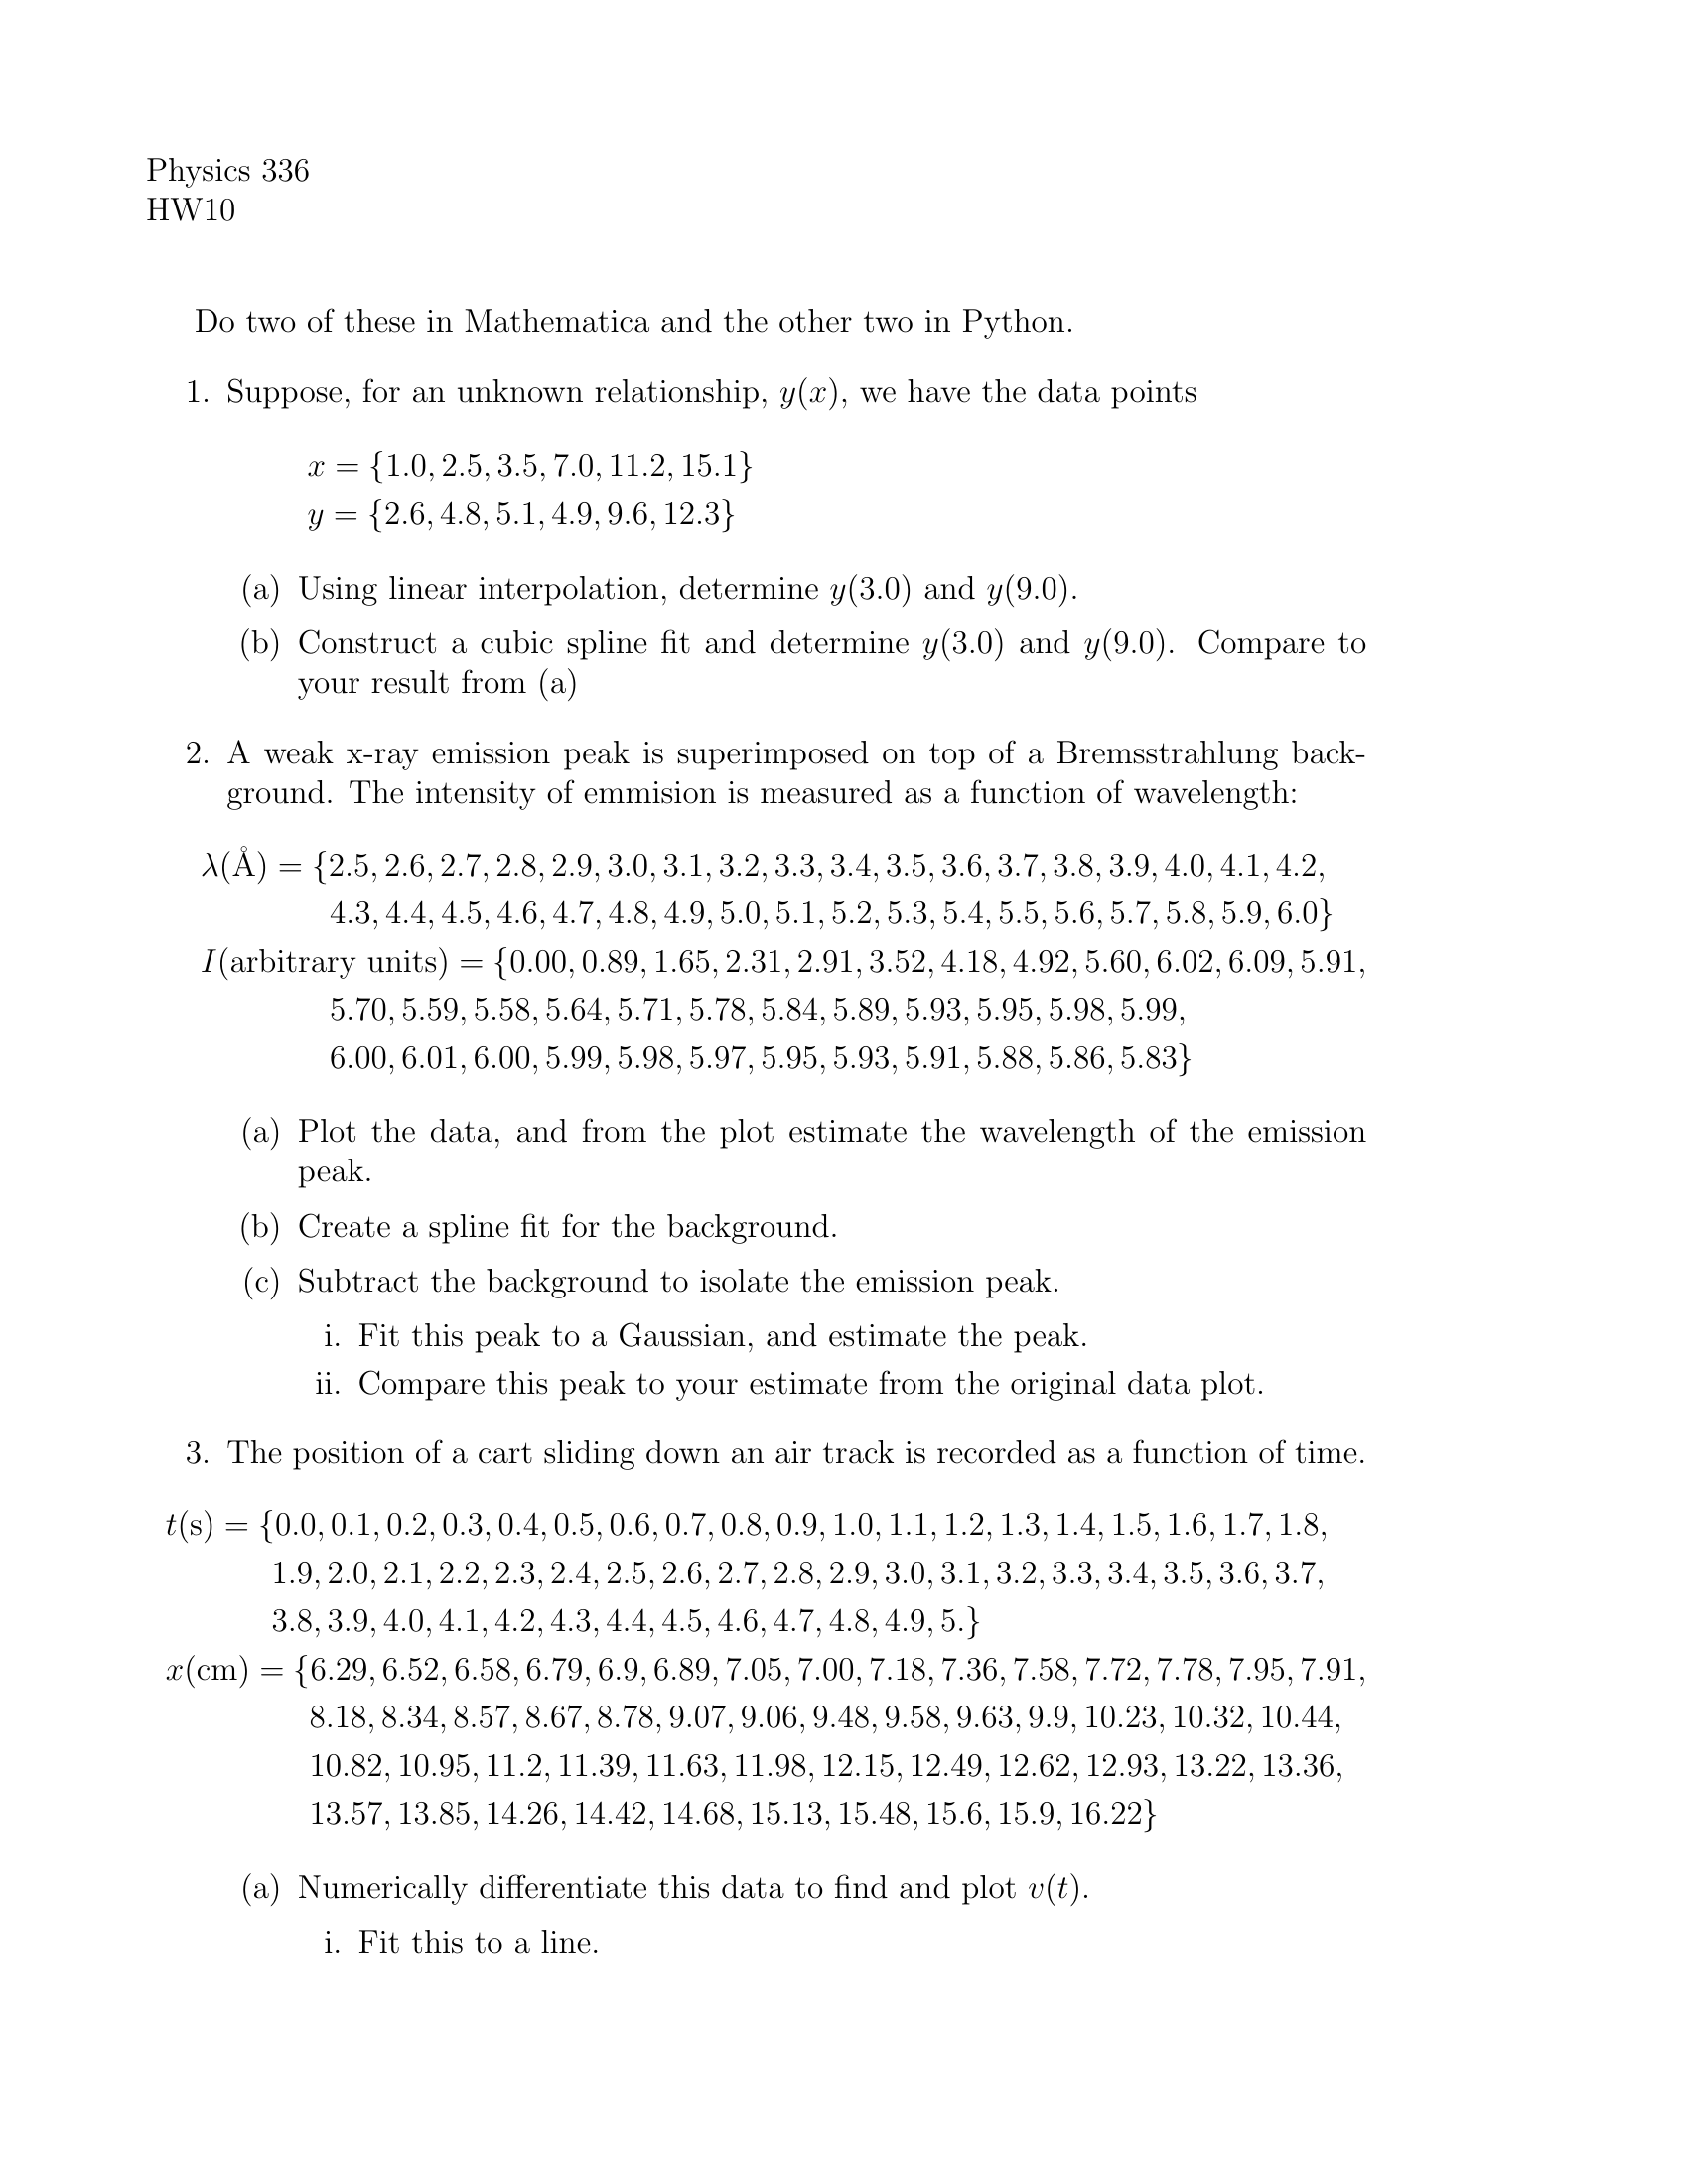

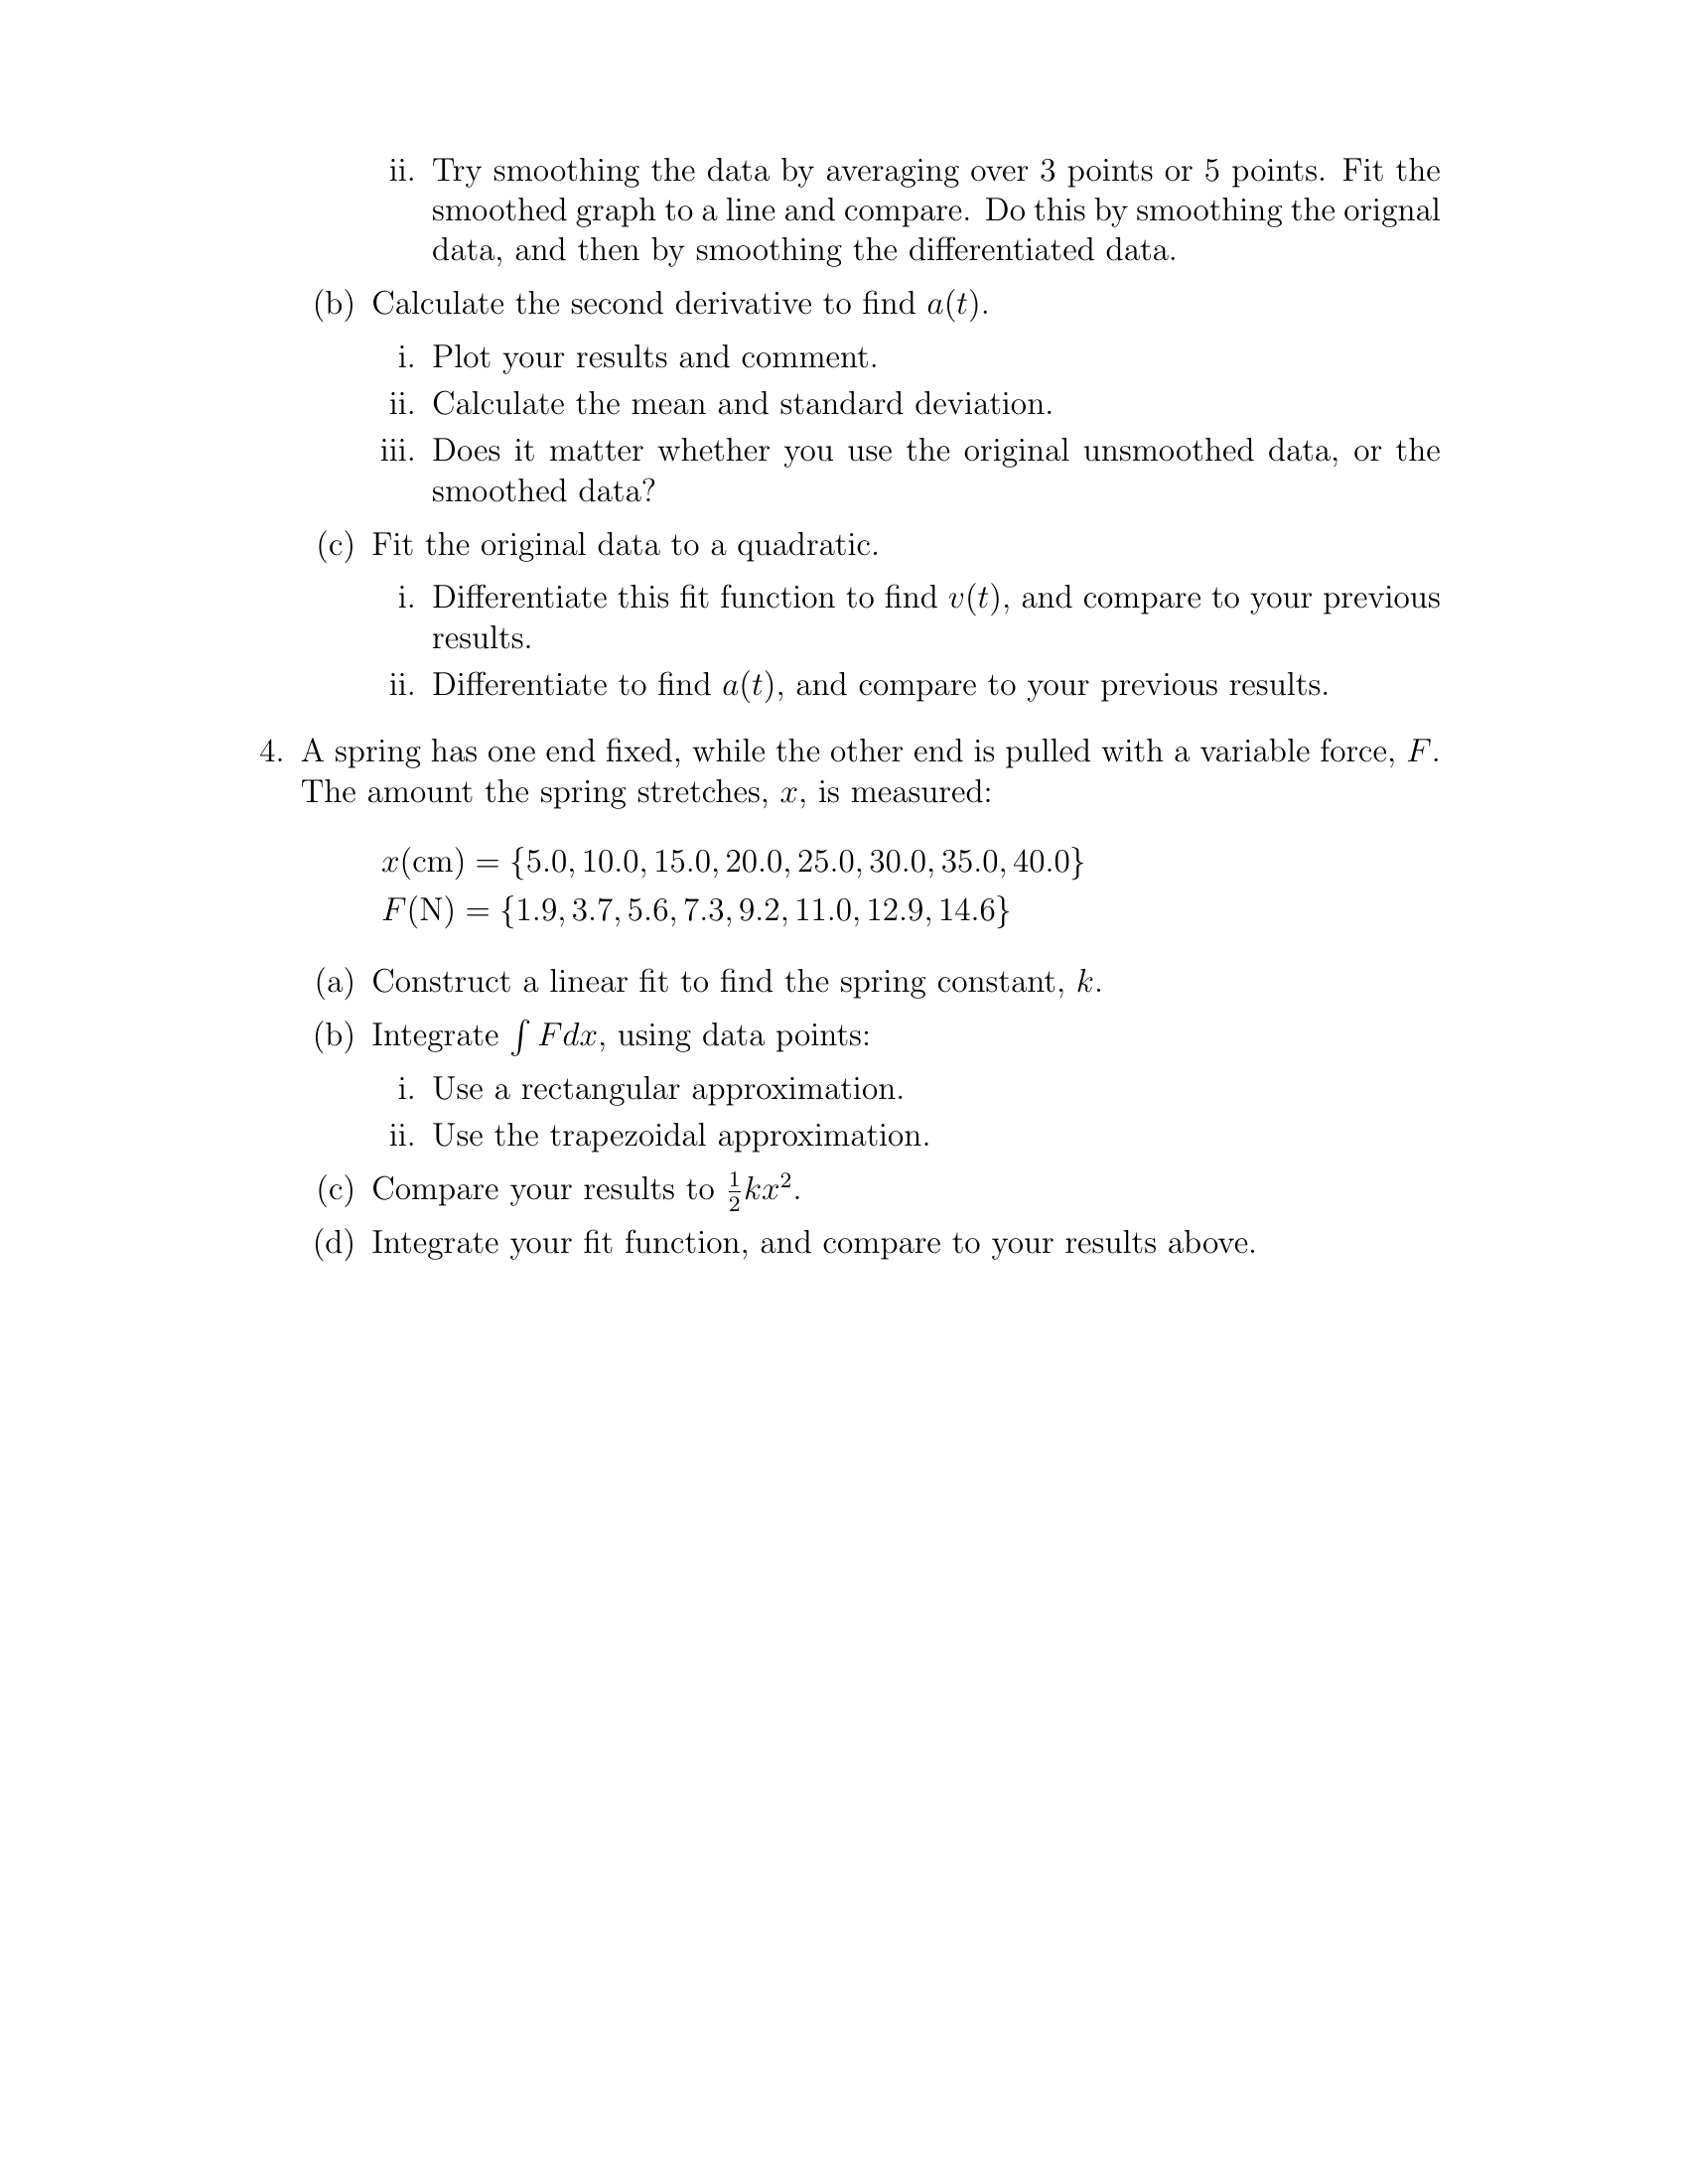

In [2]:
from pdf2image import convert_from_path
from IPython.display import display
images = convert_from_path(r"C:\Users\miles\BYU-Idaho\11th Semester\336 Advanced Lab\W10\336-hw10.pdf")
for img in images:
    display(img)

### Problem 1.

At x=3, interpolated y=4.95
At x=9, interpolated y=7.14
Cubic Spline at x=3: 5.0262
Cubic Spline at x=9: 6.6277


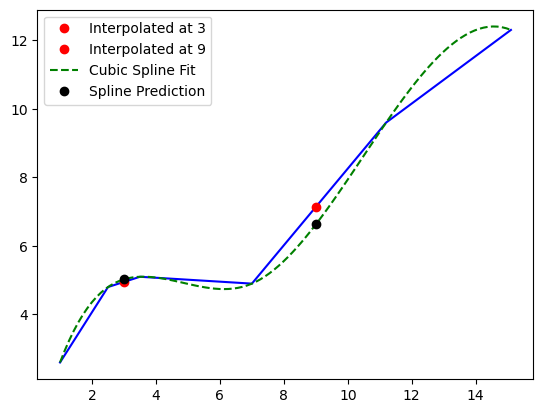

In [27]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline

x=[1.0, 2.5, 3.5, 7.0, 11.2, 15.1]
y=[2.6, 4.8, 5.1, 4.9, 9.6, 12.3]

##### Part a, linear interpolation #####
def linear(x_in):
    for i, x_val in enumerate(x):
        if x_val < x_in:
            idx = i
        else:
            break
    x1,x2 = x[idx], x[idx+1]
    y1,y2 = y[idx], y[idx+1]
    return y1 + (y2-y1)/(x2-x1)*(x_in-x1)

points=[3,9]

plt.plot(x,y, color = "blue")
for i in points:
    y_out = linear(i)
    plt.plot(i, y_out,'ro', label=f"Interpolated at {i}")
    print(f"At x={i}, interpolated y={y_out:.2f}")


##### Part b, cubic interpolation #####

CS = CubicSpline(x,y)
y_spline = CS(points)

x_smooth = np.linspace(min(x), max(x), 100)
y_smooth = CS(x_smooth)

plt.plot(x_smooth, y_smooth, label = "Cubic Spline Fit", color="green", linestyle="--")
plt.plot(points, y_spline, 'ko', label = "Spline Prediction")

for i, val in enumerate(points):
    print(f"Cubic Spline at x={val}: {y_spline[i]:.4f}")

plt.legend()
plt.show()  

### Problem 2

Wavelength of emission peak: 3.5 Angstrom
Estimated Peak Center (Wavelength): 3.3911 Angstrom


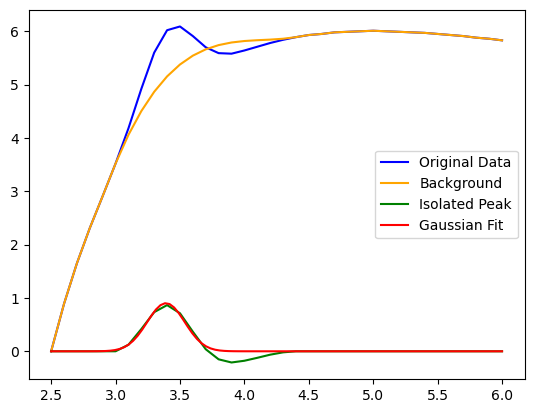

In [102]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit

lam = [2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 
       3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 
       4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6.0]

I = [0.00, 0.89, 1.65, 2.31, 2.91, 3.52, 4.18, 4.92, 5.60, 6.02, 
     6.09, 5.91, 5.70, 5.59, 5.58, 5.64, 5.71, 5.78, 5.84, 5.89, 
     5.93, 5.95, 5.98, 5.99, 6.00, 6.01, 6.00, 5.99, 5.98, 5.97, 
     5.95, 5.93, 5.91, 5.88, 5.86, 5.83]

#### Part a, Plot the data and estimate the wavelength of the emission peak. ####
plt.plot(lam,I, label = "Original Data", color = "blue")
peak=lam[I.index(max(I))]
print(f"Wavelength of emission peak: {peak} Angstrom")


#### Part b, Create a spline fit for the background ####
lam_bg=[]
I_bg = []

for i in range(len(lam)):
    if lam[i] < 3.1 or lam[i] > 4.3:
        lam_bg.append(lam[i])
        I_bg.append(I[i])       
        
lam_bg=np.array(lam_bg)   
I_bg=np.array(I_bg) 

CS_bg=CubicSpline(lam_bg, I_bg)
background = CS_bg(lam)

#### Part c, Subtract the background to isolate the emission peak. ####
#### i. Fit this peak to a Gaussian, and estimate the peak. ####
#### ii. Compare this peak to your estimate from the original data plot. ####

I_peak = np.array(I) - background

def gauss(x,A,x1,sigma):
    return A*np.exp(-(x-x1)**2/2/sigma**2)

max_idx=np.argmax(I_peak)
guess_A =I_peak[max_idx]
guess_x1 = lam[max_idx]
guess_sigma = 0.1

initial_guess = [guess_A ,guess_x1, guess_sigma]
popt, pcov = curve_fit(gauss,lam, I_peak, p0=initial_guess)

lam_smooth = np.linspace(min(lam), max(lam), 100)
gauss_fit = gauss(lam_smooth, *popt)

print(f"Estimated Peak Center (Wavelength): {popt[1]:.4f} Angstrom")

plt.plot(lam,background, label = "Background", color = "orange")
plt.plot(lam, I_peak, label= "Isolated Peak", color = "green")
plt.plot(lam_smooth, gauss_fit, "r-", label = "Gaussian Fit")
plt.legend()
plt.show()

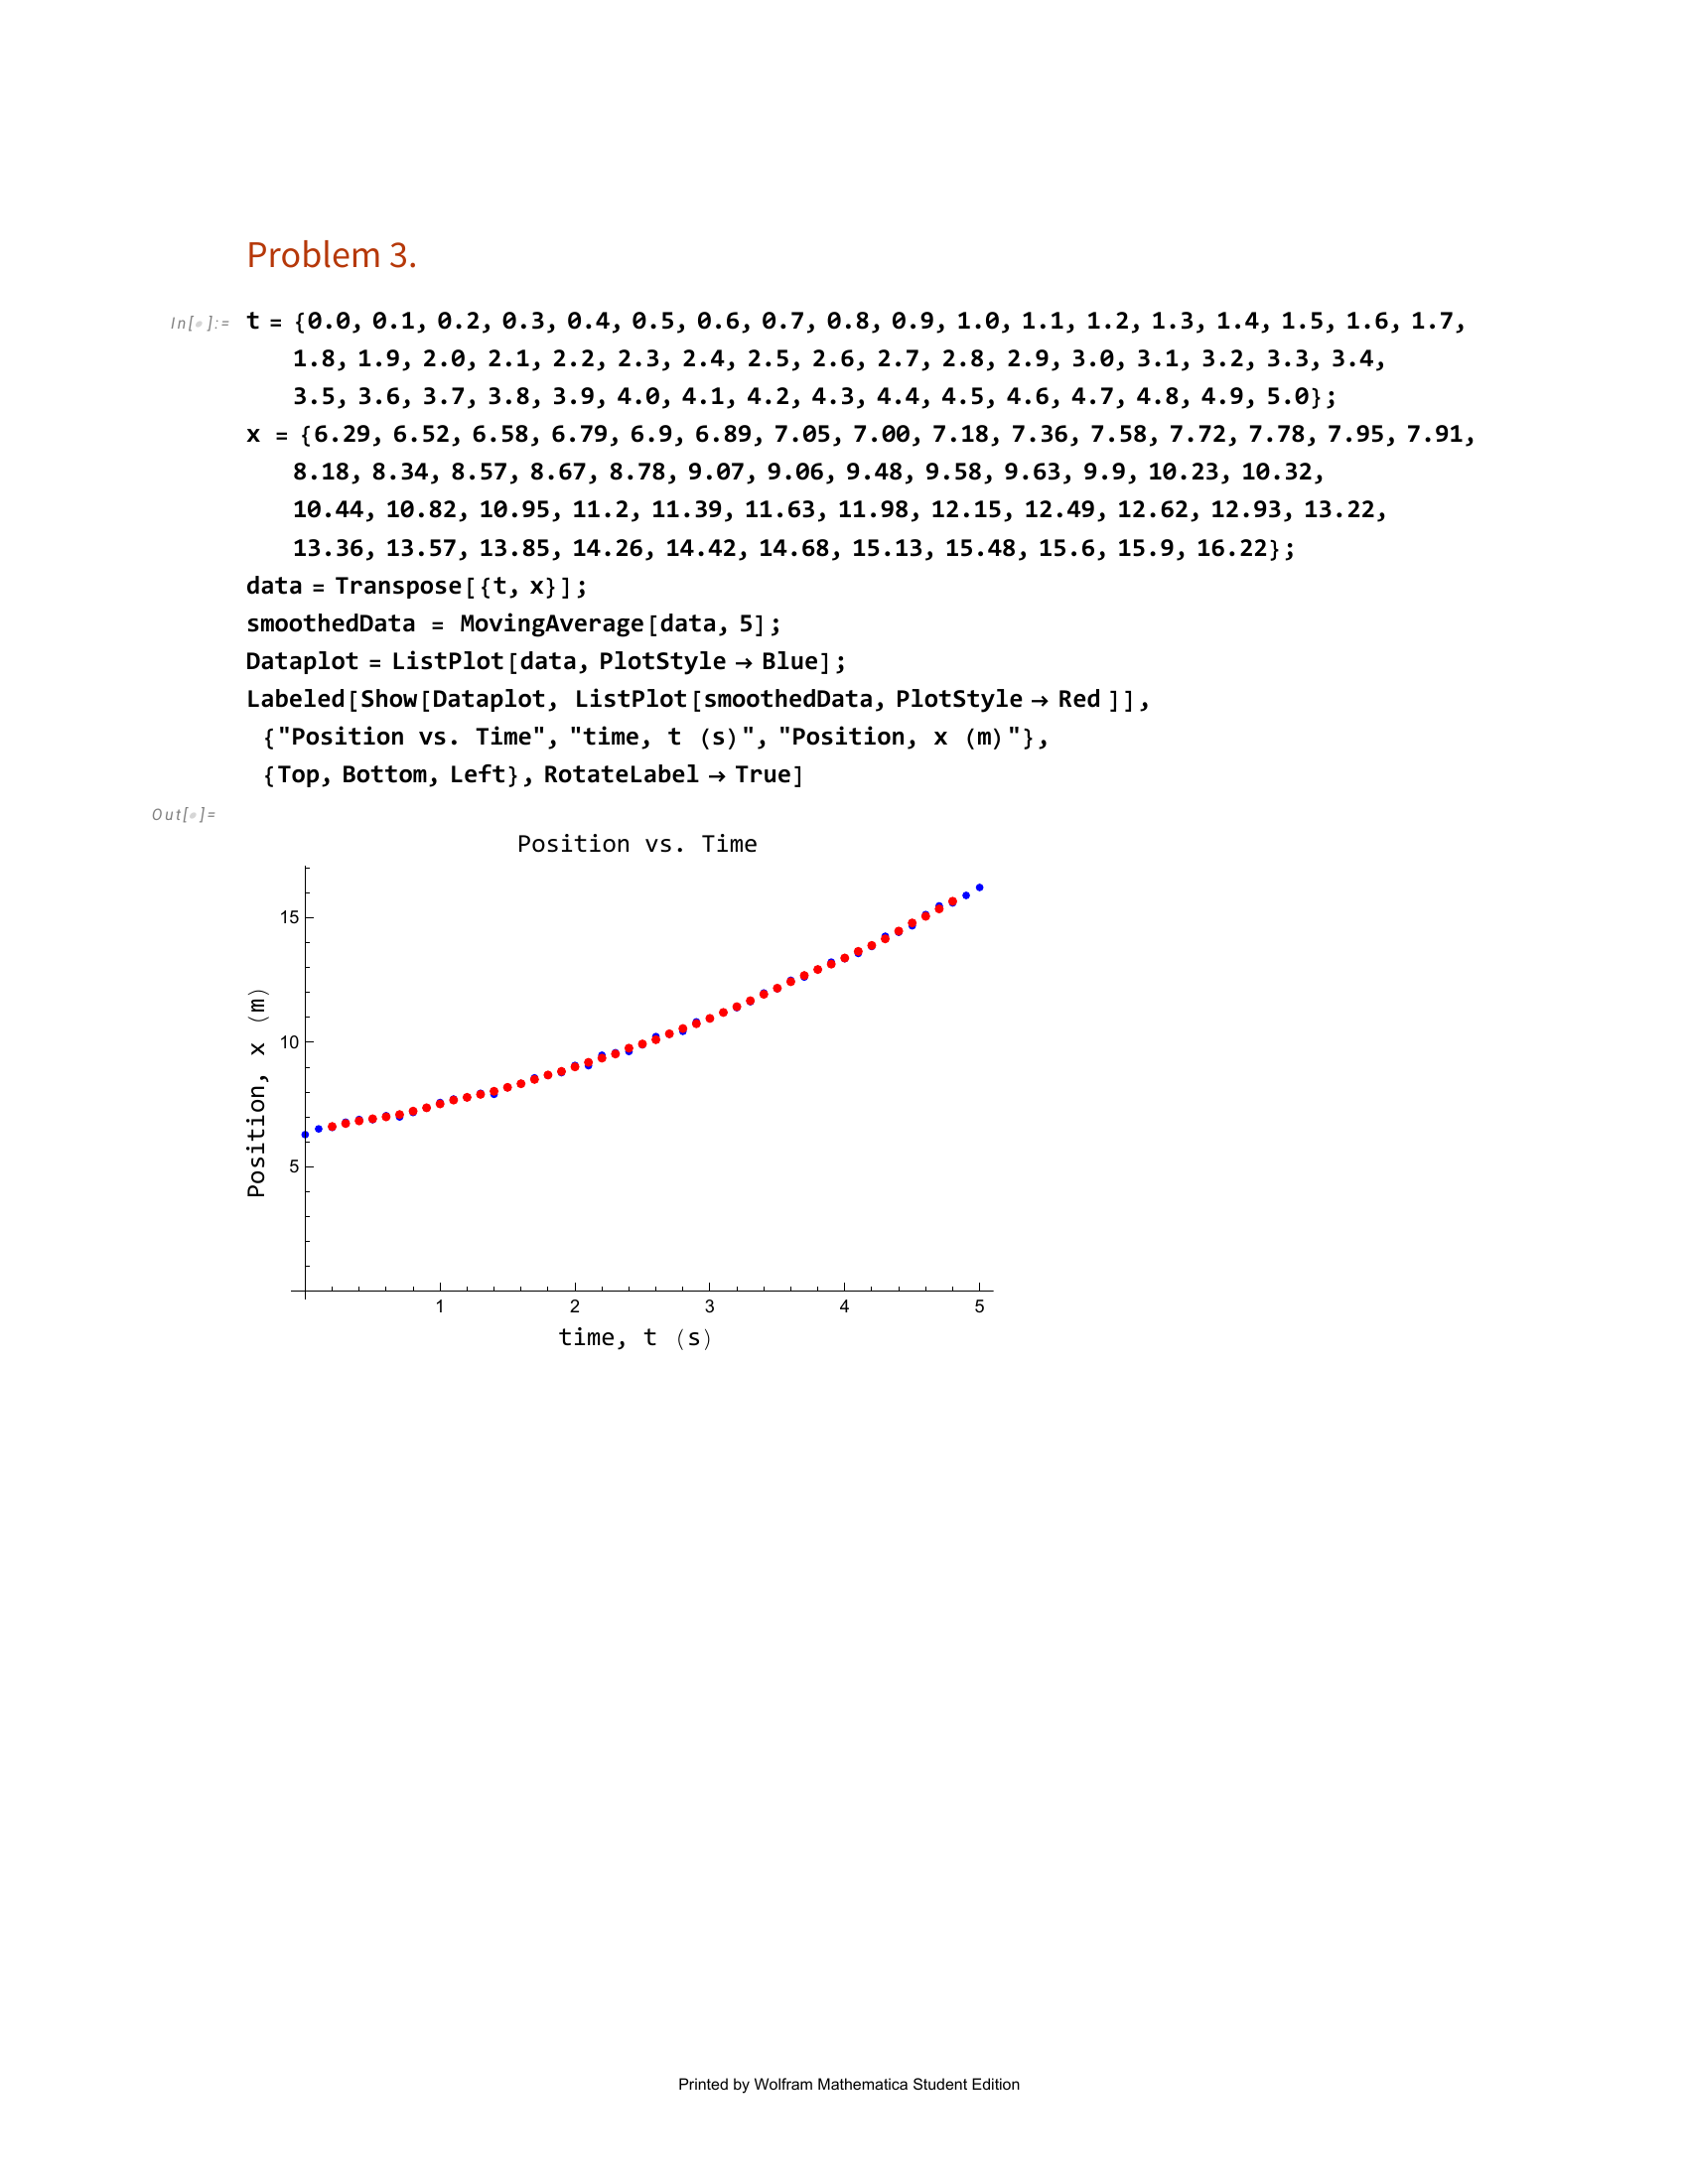

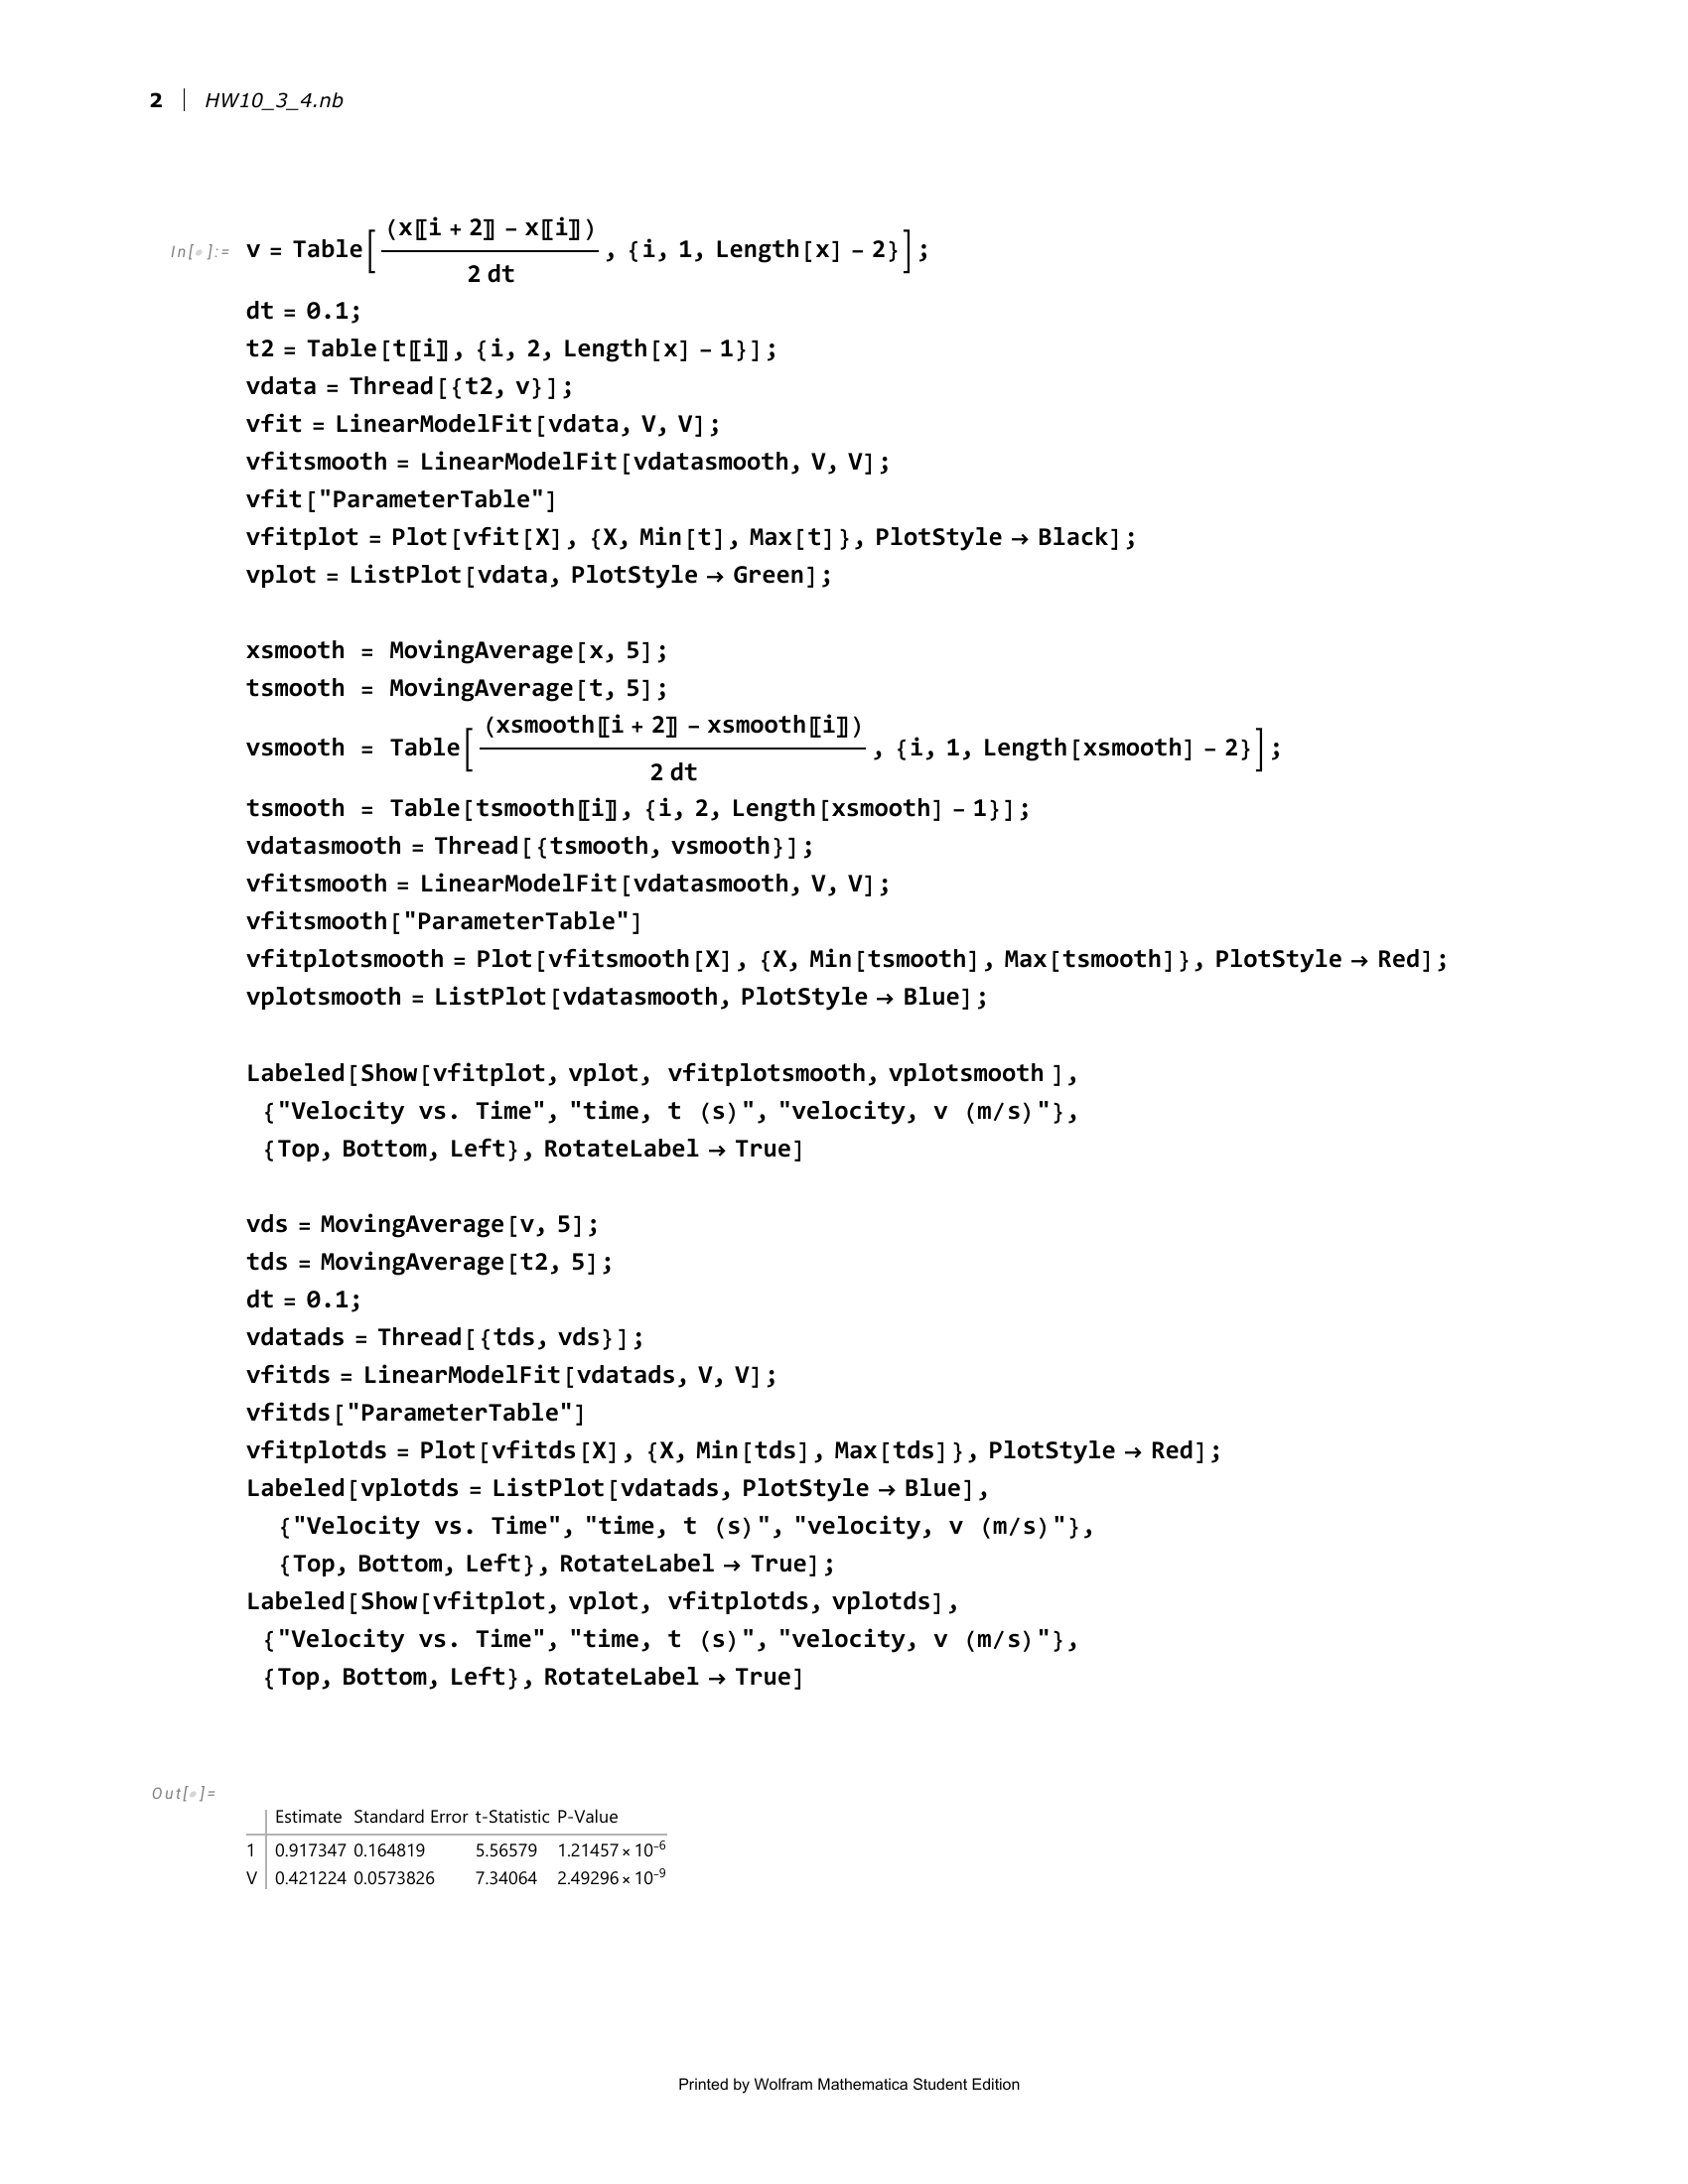

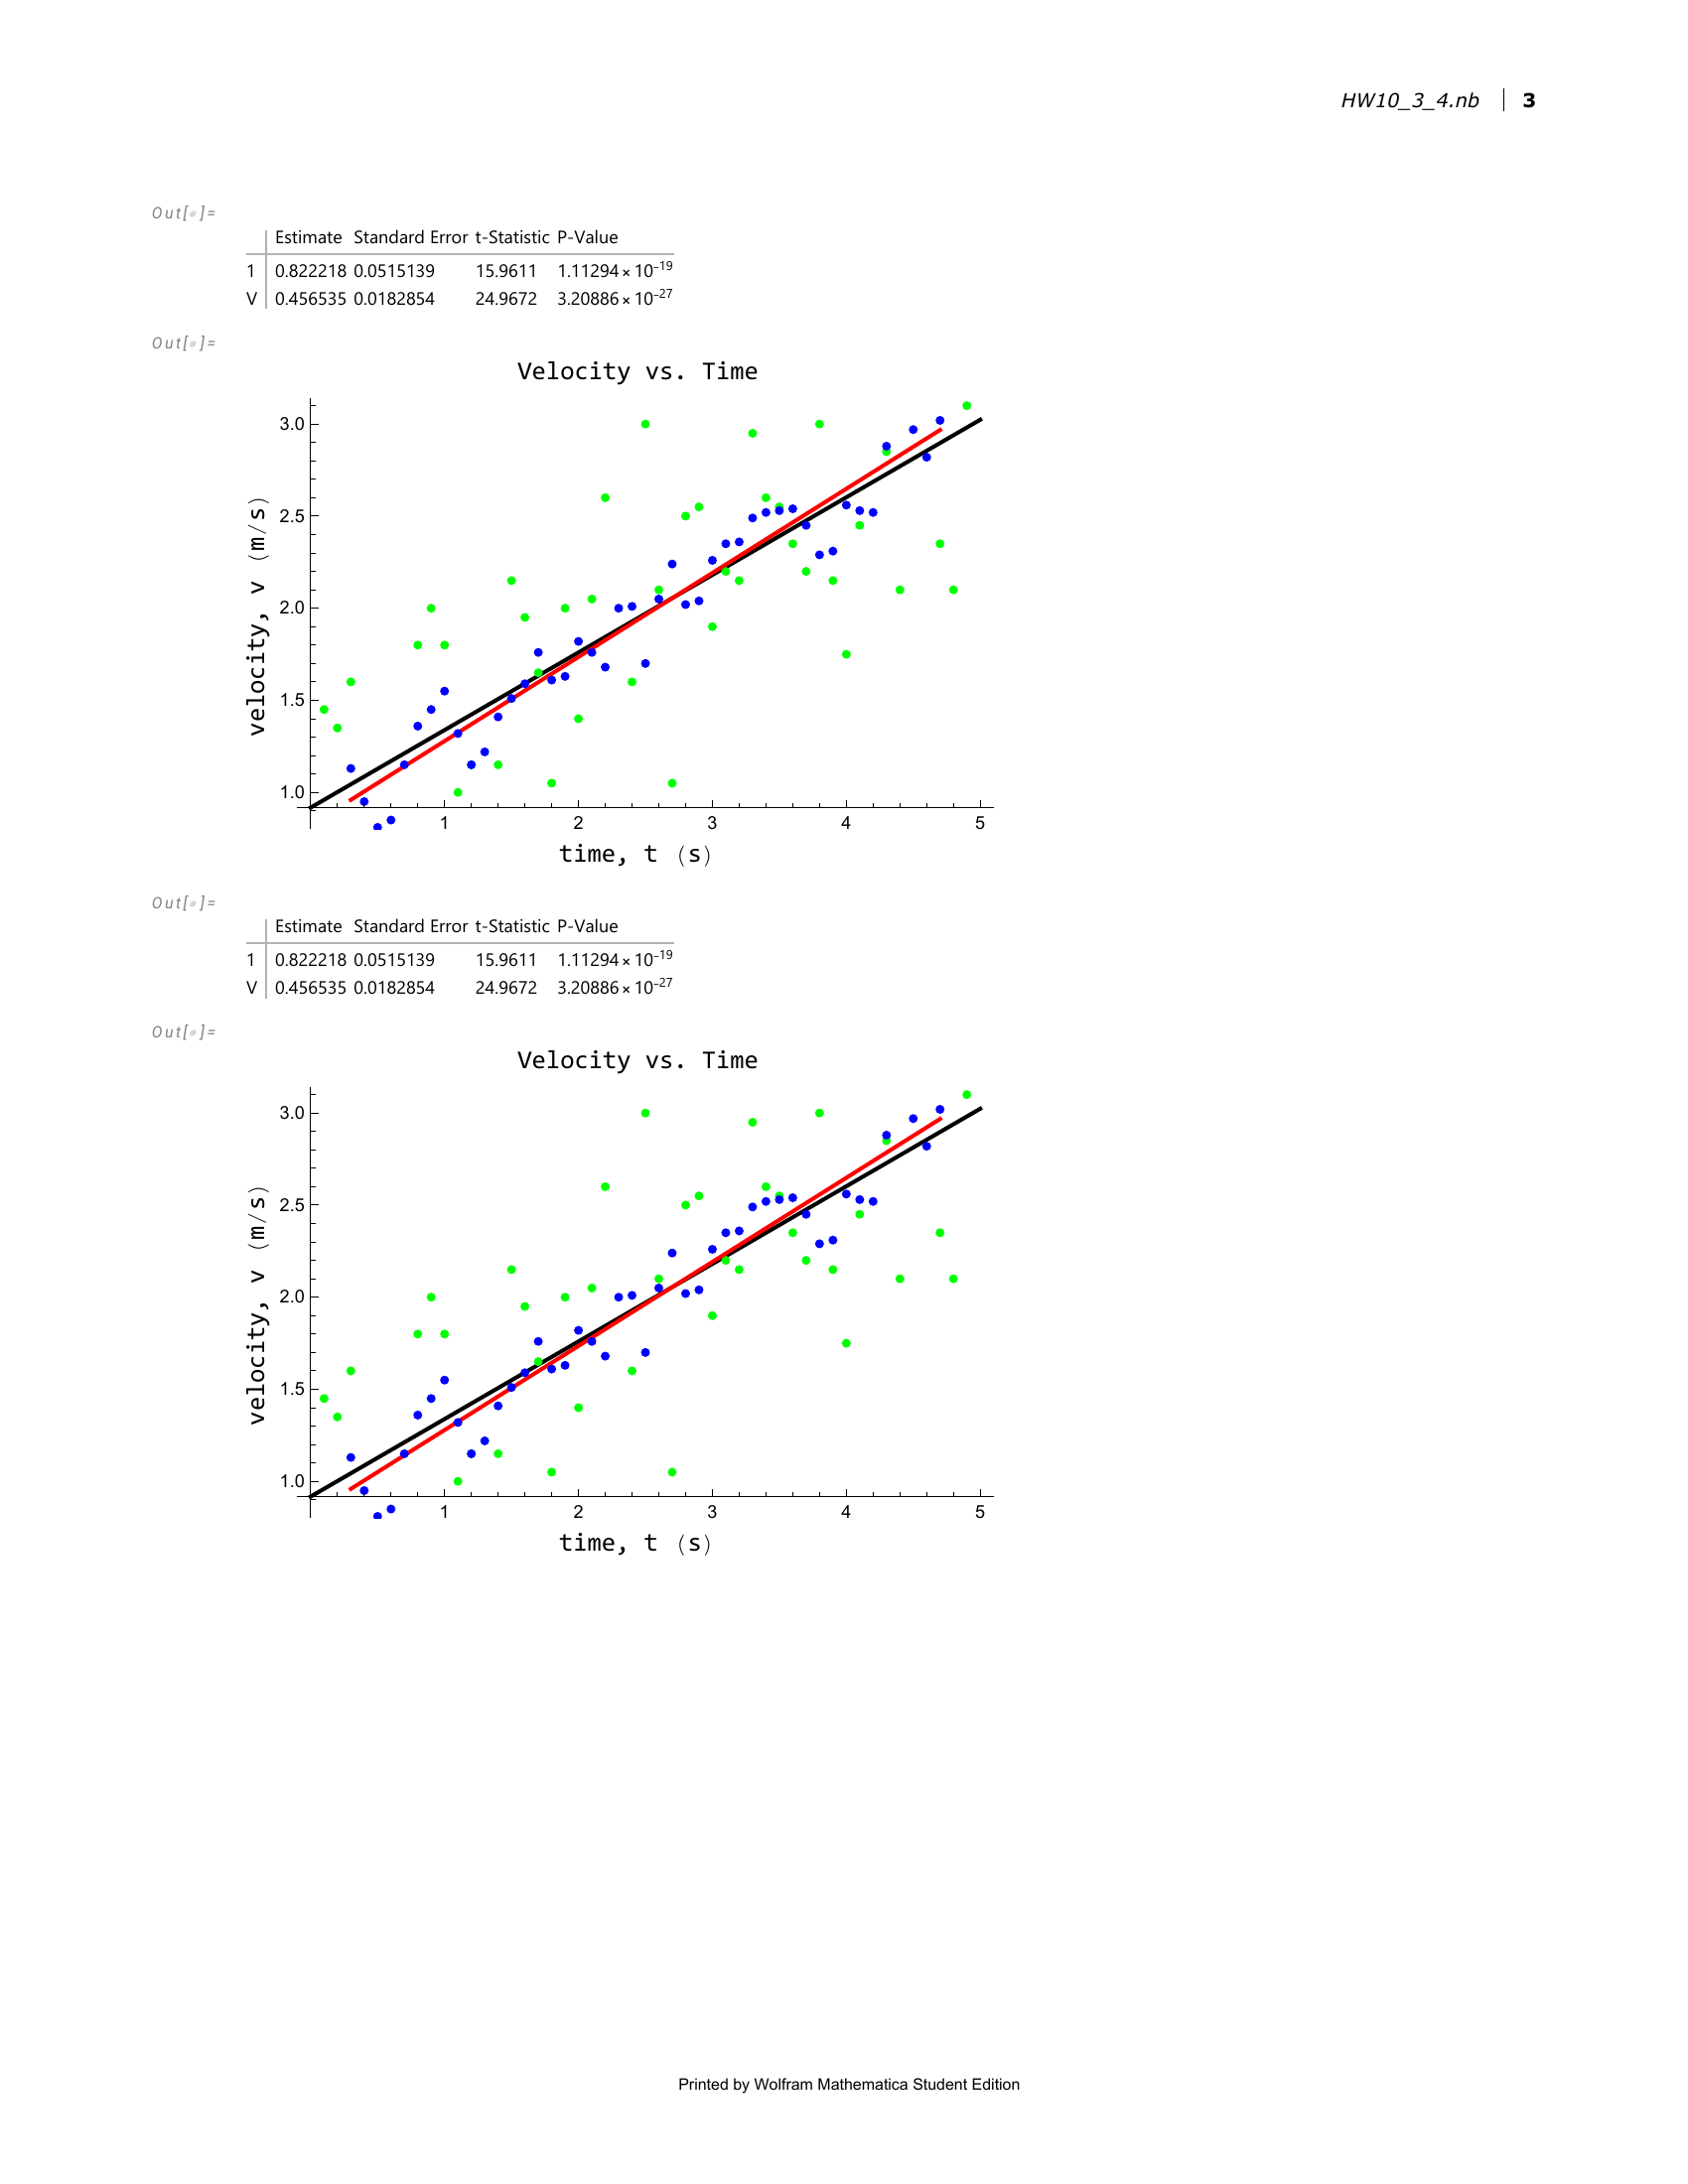

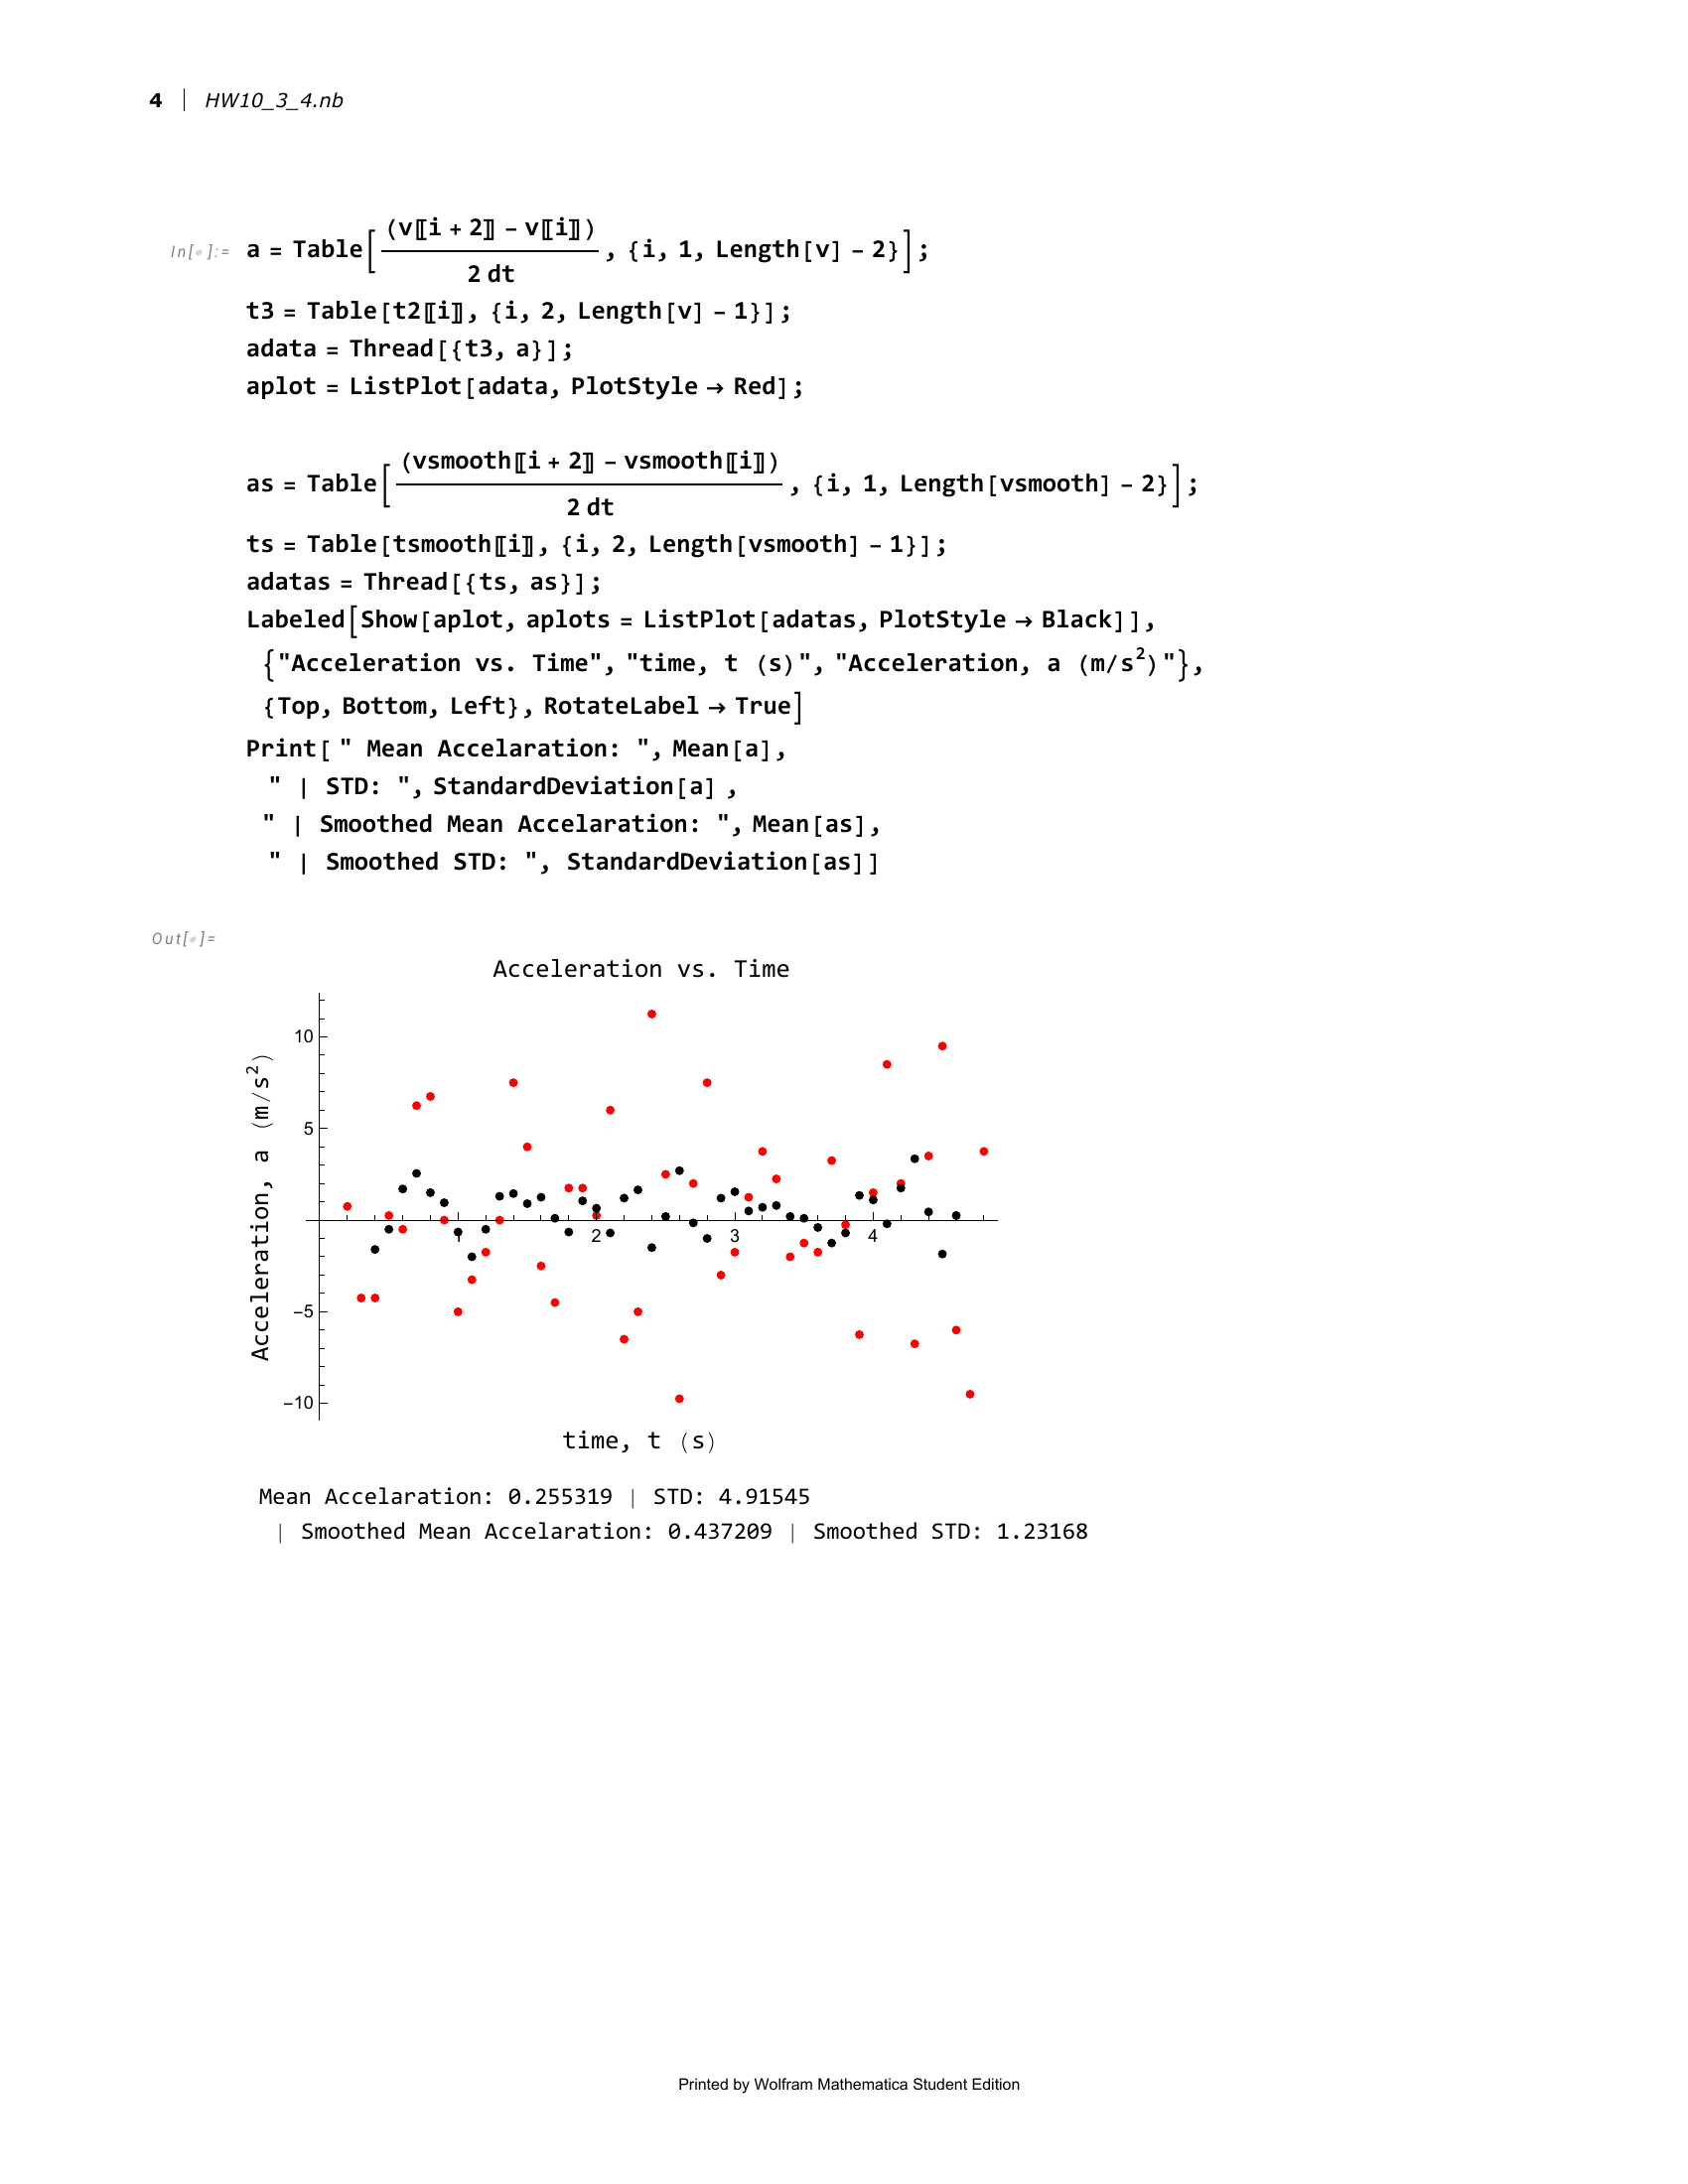

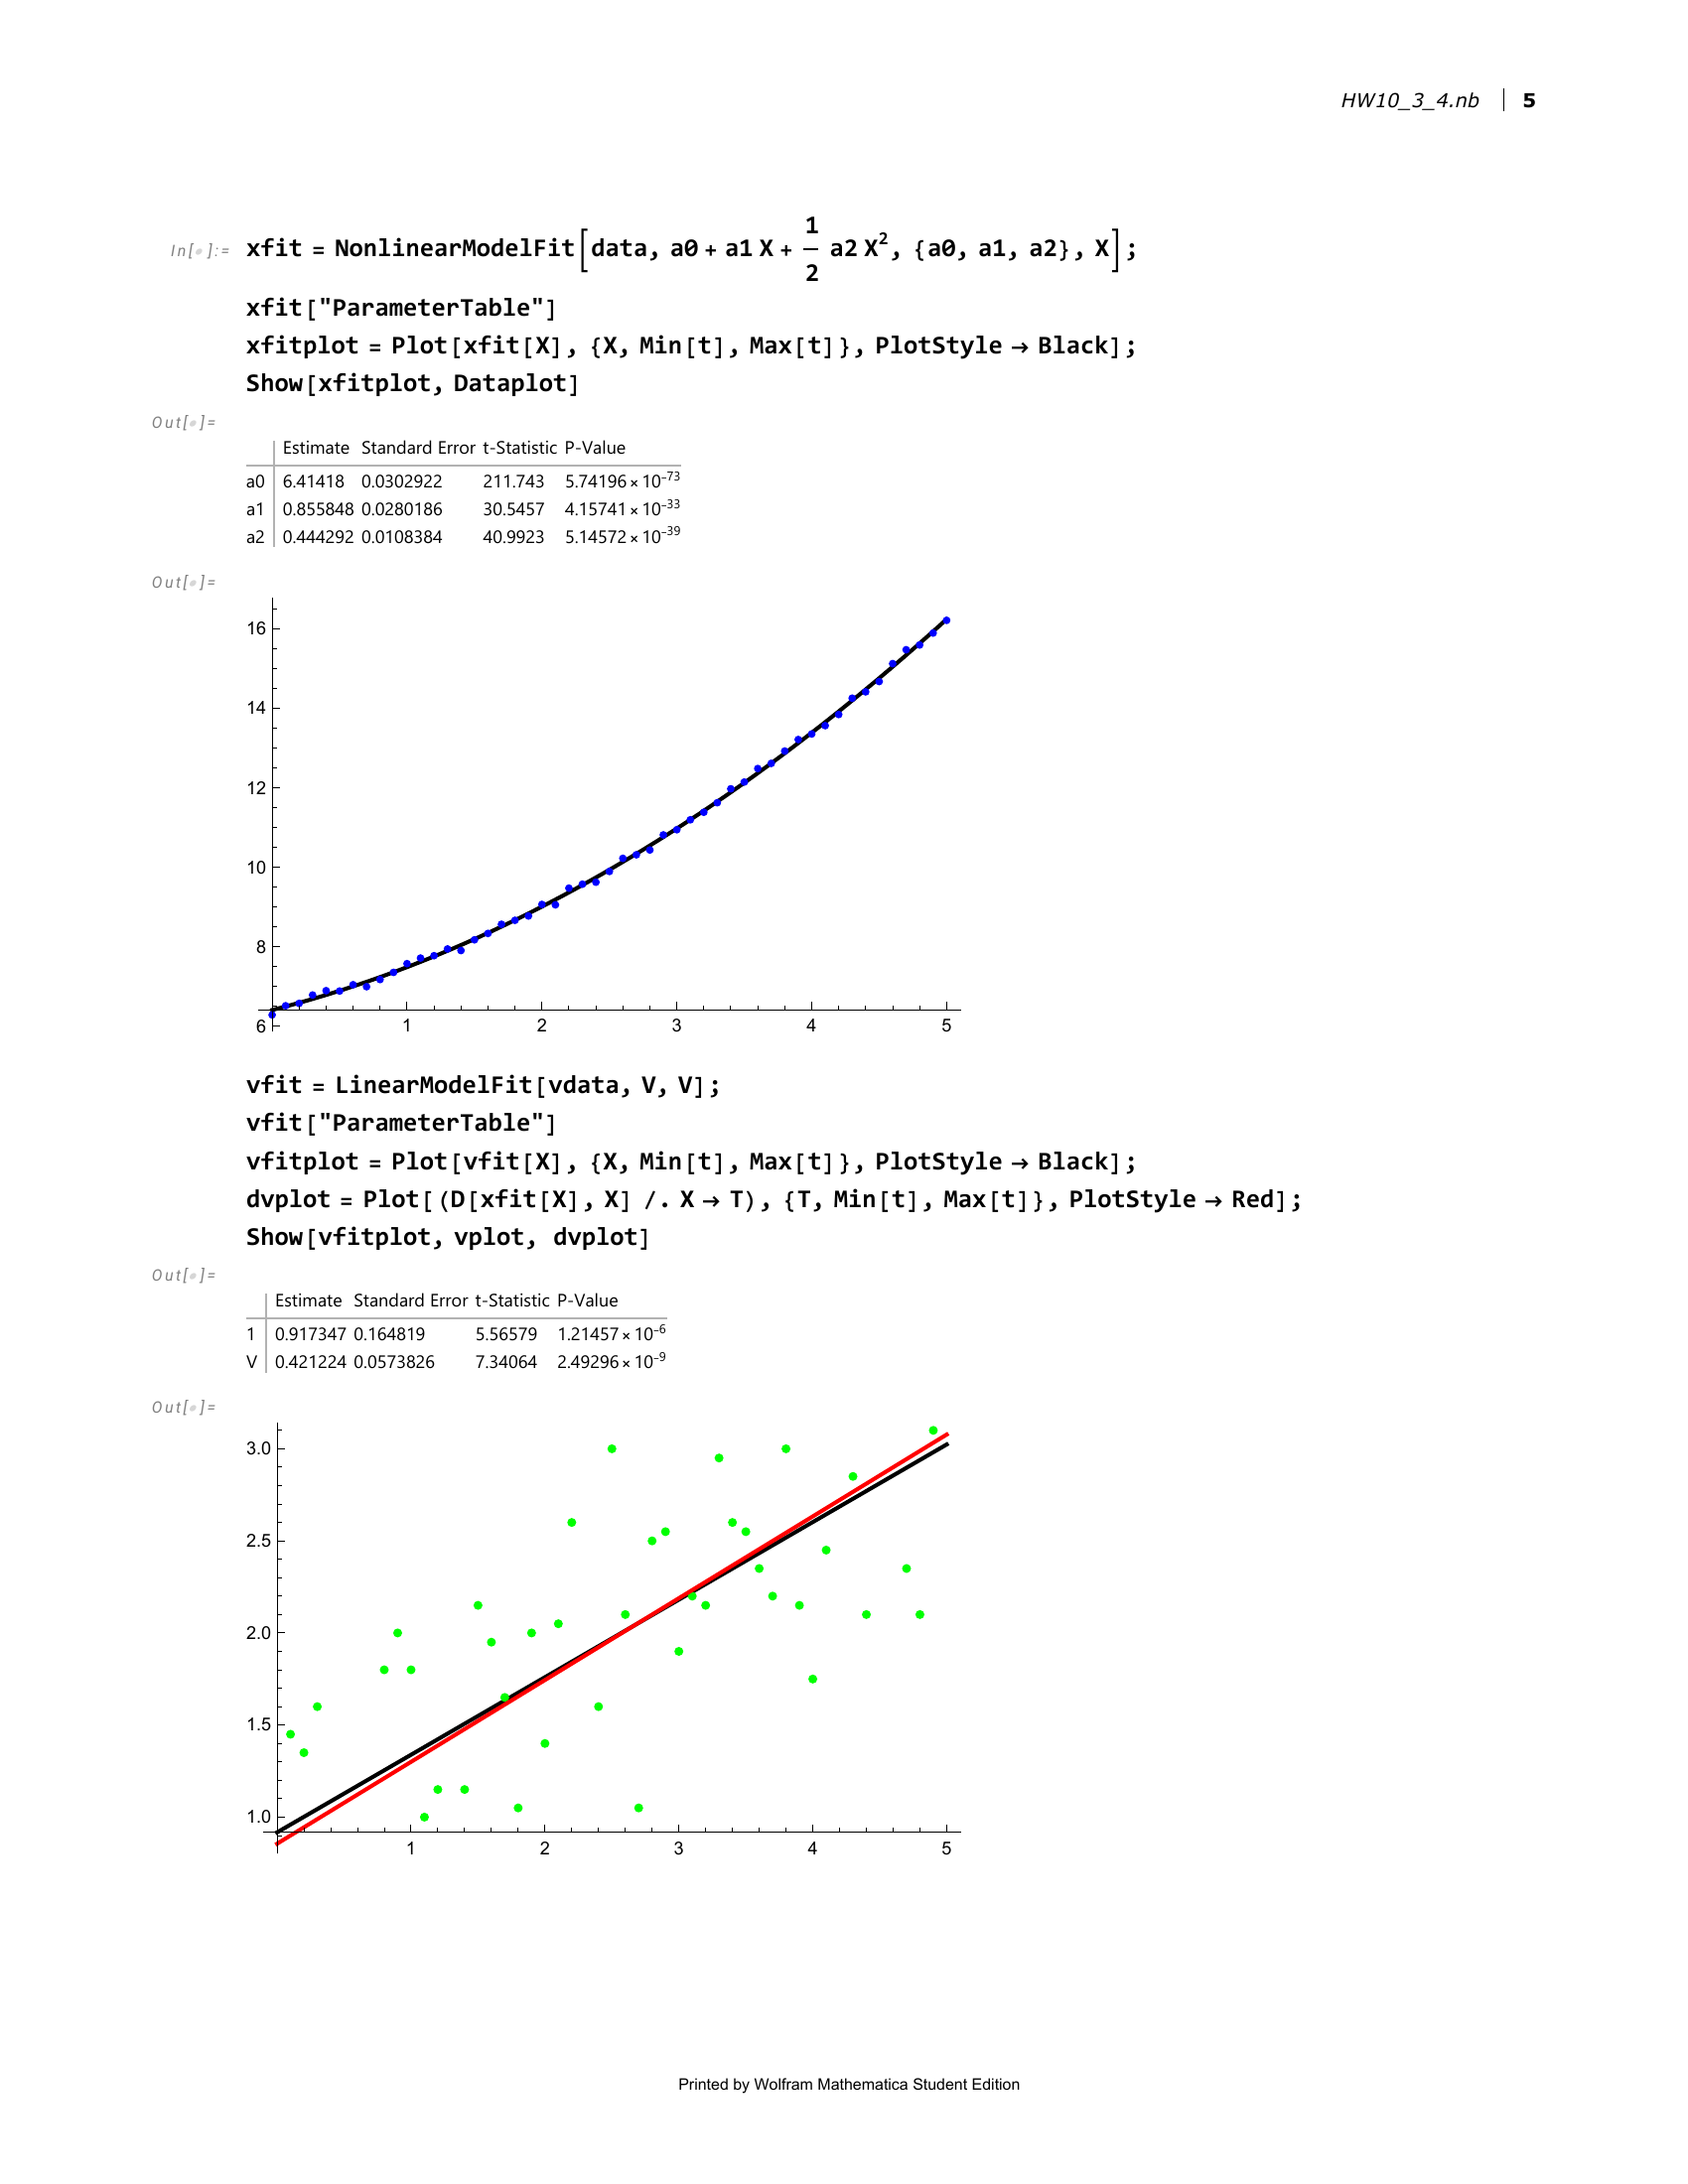

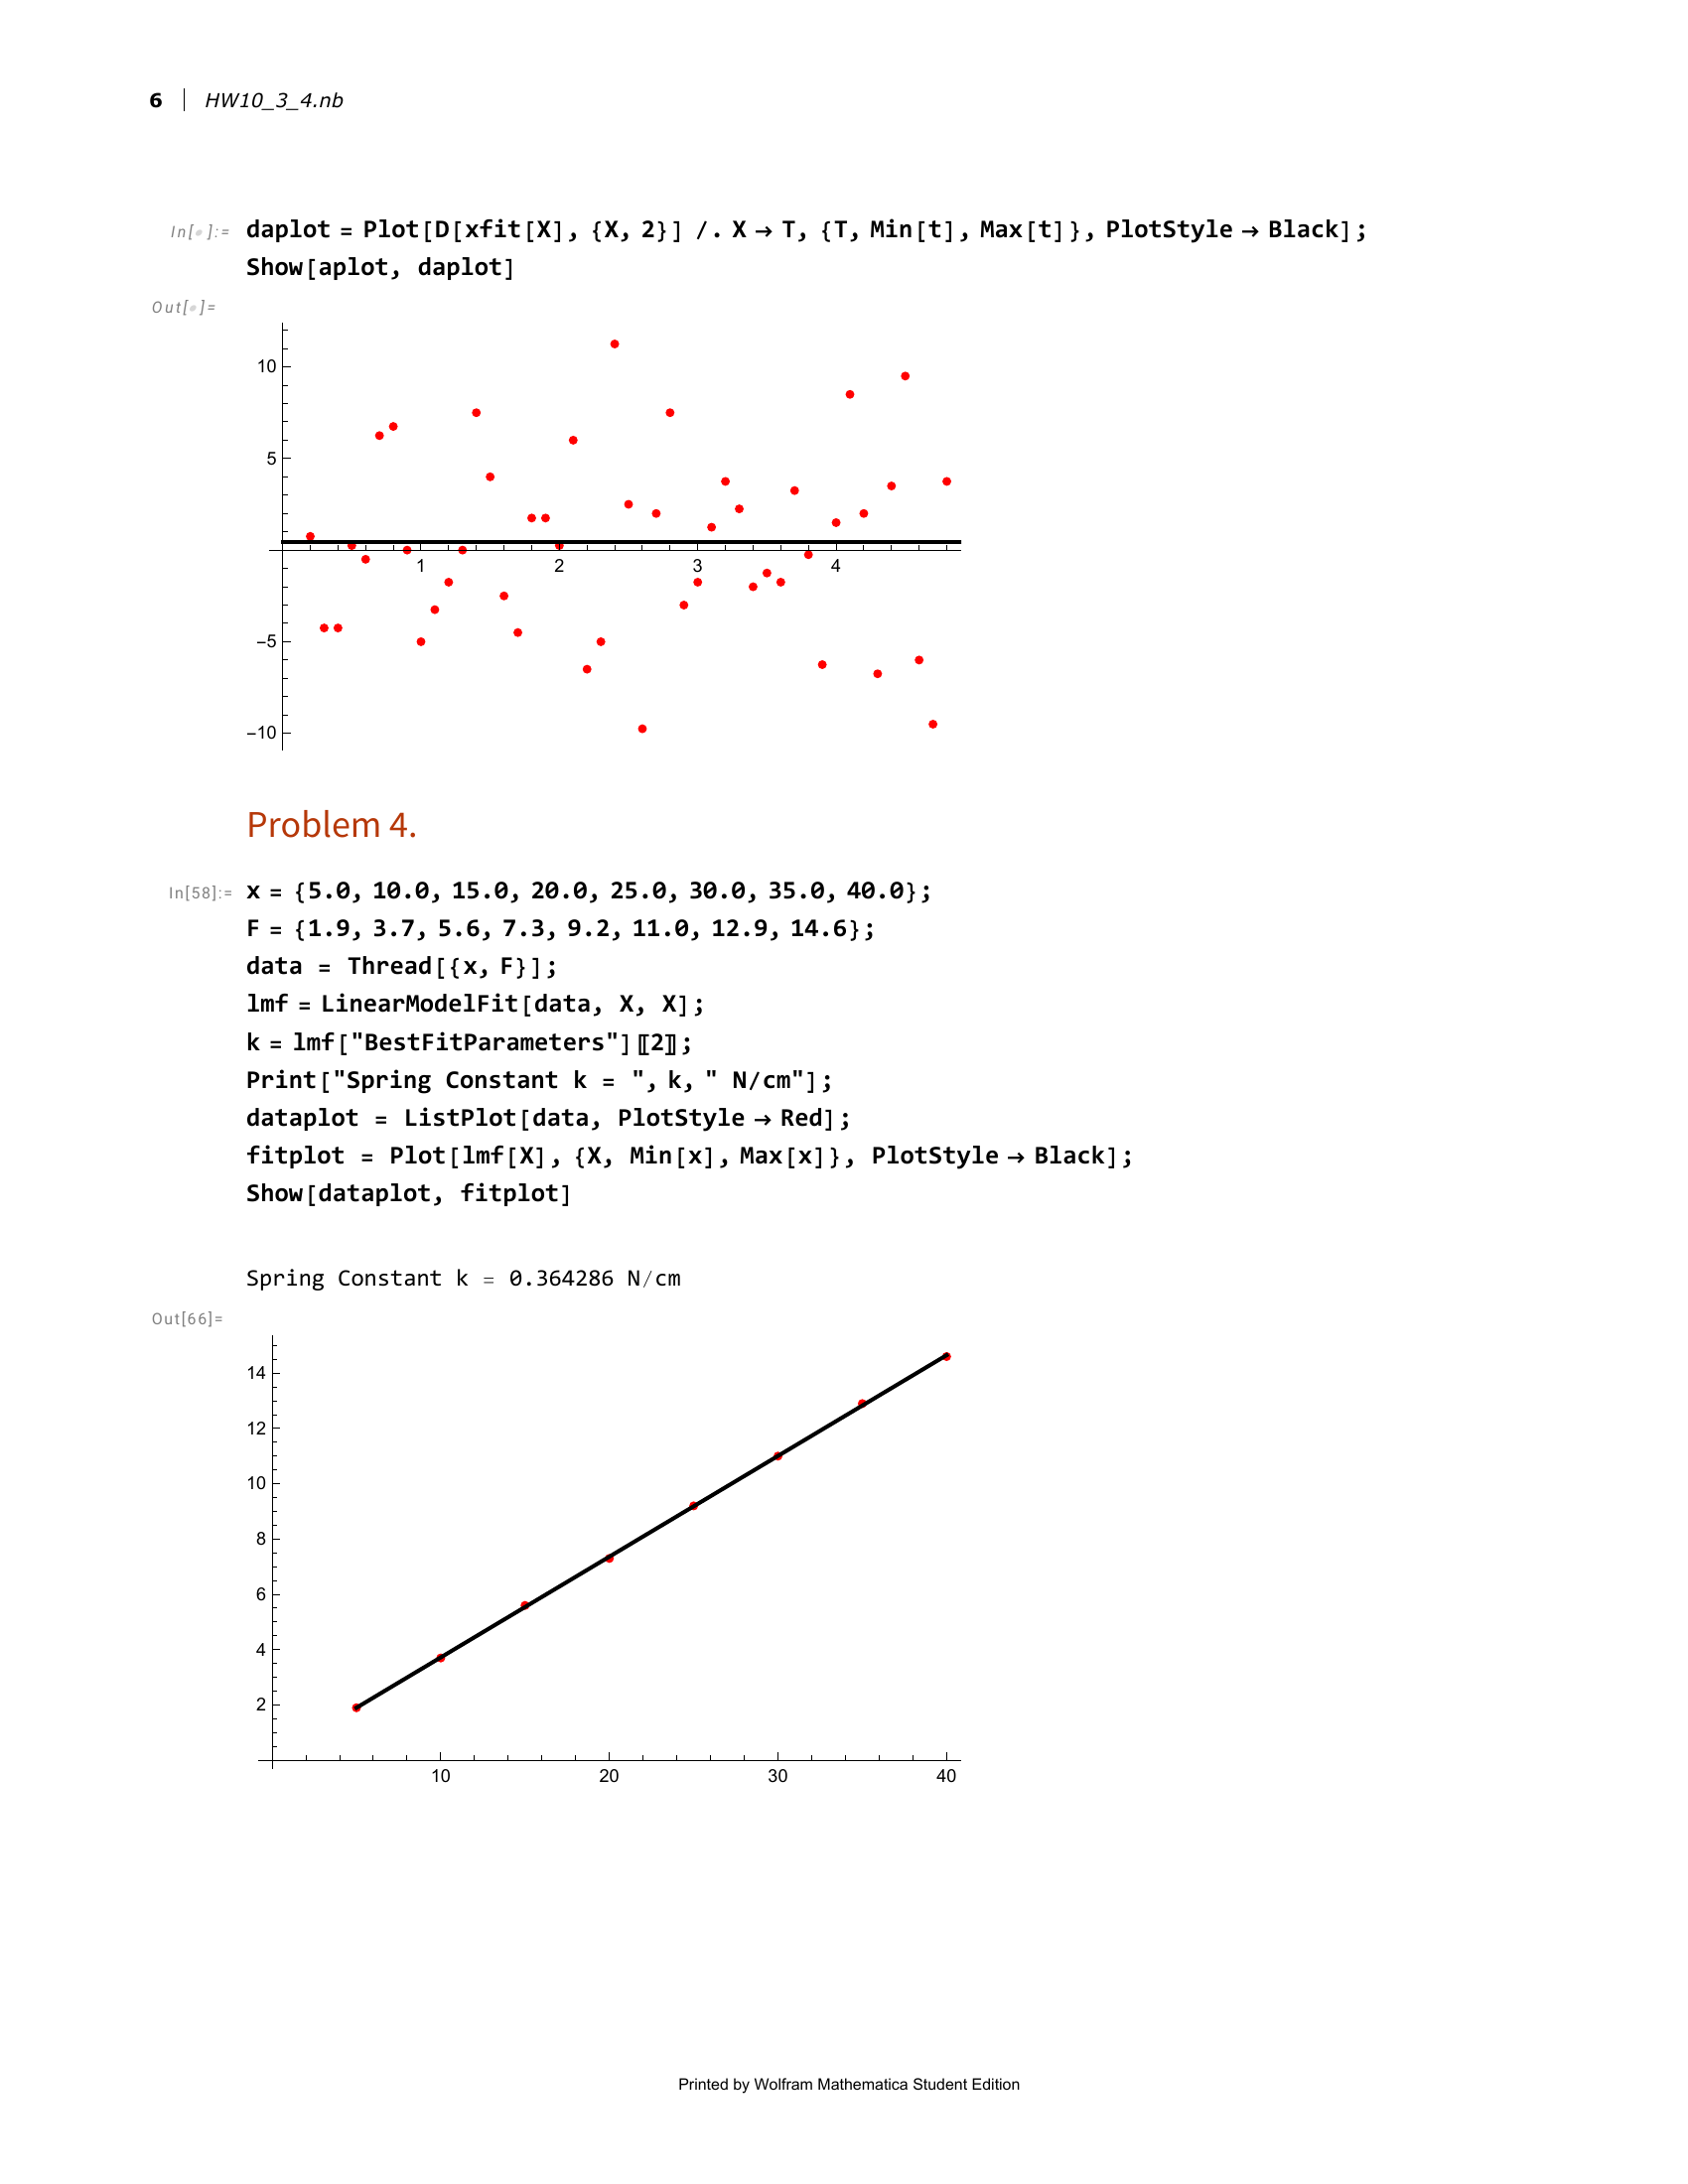

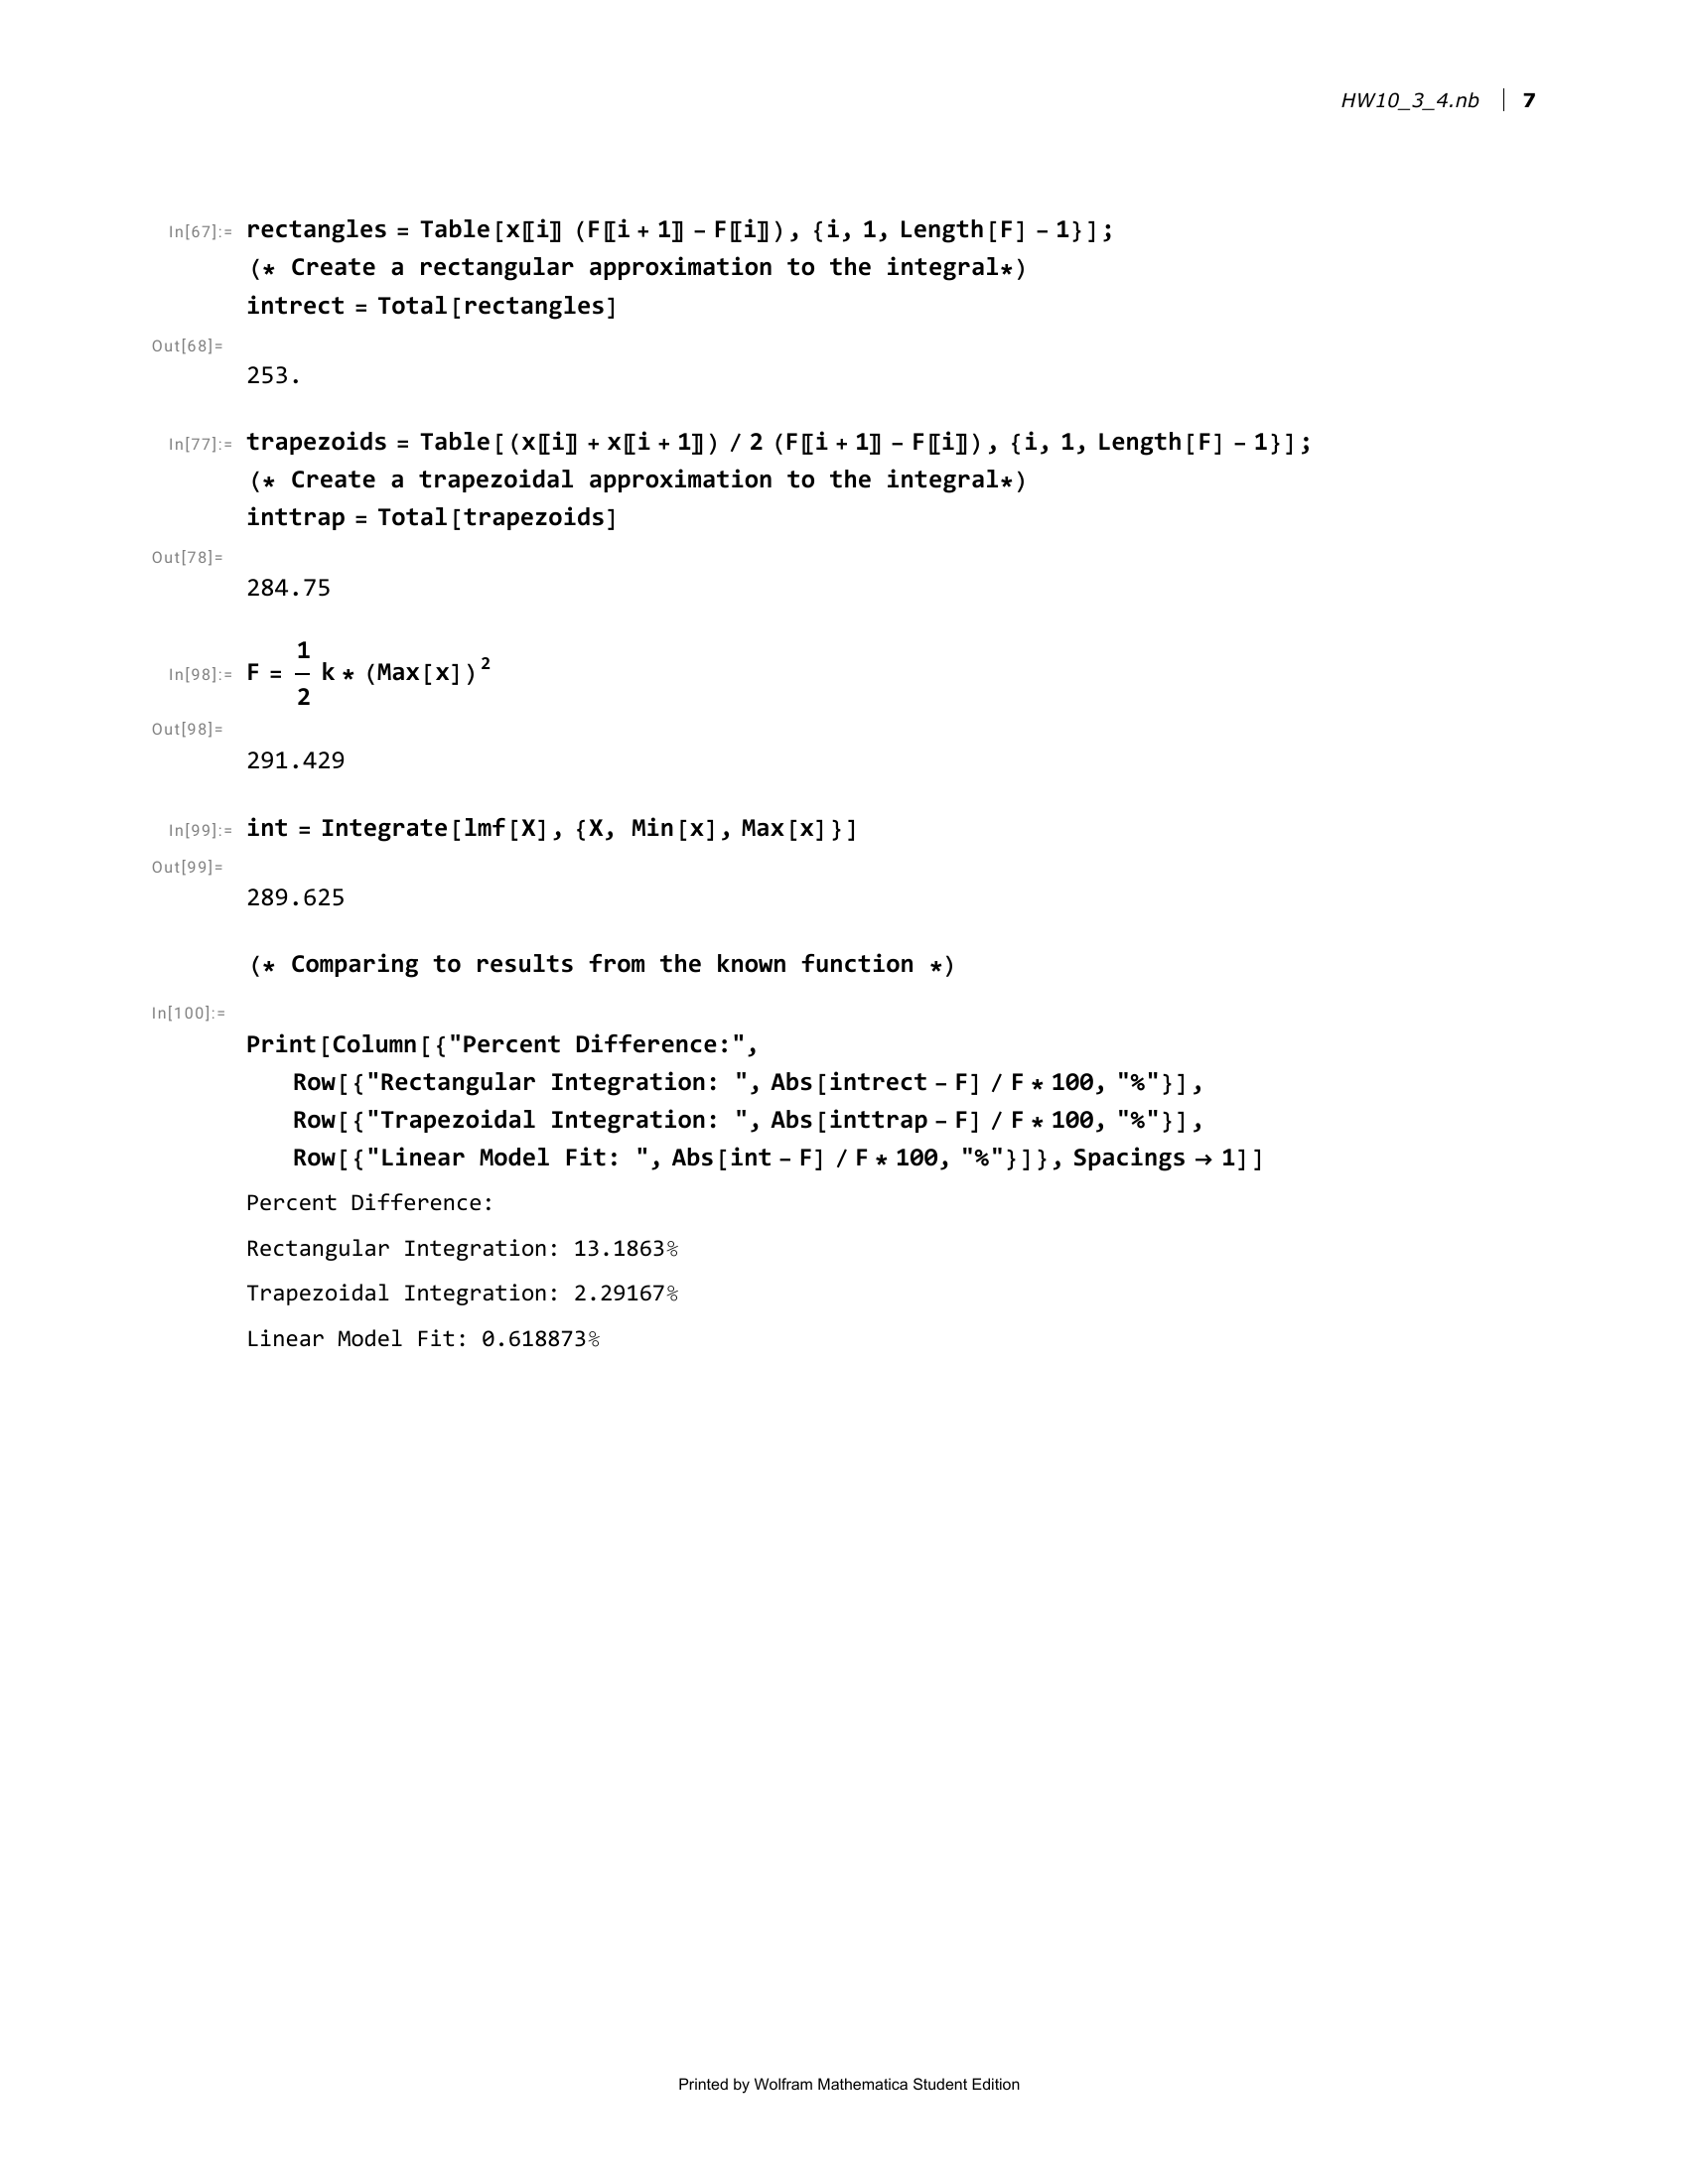

In [103]:
from pdf2image import convert_from_path
from IPython.display import display
images = convert_from_path(r"C:\Users\miles\BYU-Idaho\11th Semester\336 Advanced Lab\W10\HW10_3_4.pdf")
for img in images:
    display(img)